# 1

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# Sample small dataset (A short story snippet)
text = "In the light of the moon a little egg lay on a leaf."
words = text.lower().replace('.', '').split()

# Create vocabulary mapping
vocab = sorted(list(set(words)))
word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

# Prepare sequences: use a window of 3 words to predict the next word
seq_length = 3
dataX, dataY = [], []
for i in range(len(words) - seq_length):
    dataX.append([word_to_ix[w] for w in words[i:i + seq_length]])
    dataY.append(word_to_ix[words[i + seq_length]])

X = torch.tensor(dataX, dtype=torch.long) # Shape: [N, seq_length]
y = torch.tensor(dataY, dtype=torch.long) # Shape: [N]

In [9]:
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(WordLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]) # Use the last hidden state

model = WordLSTM(vocab_size, embed_dim=16, hidden_dim=32)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(200):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    if epoch%10==0:
        print(f"Loss: {loss:.4f}")


Loss: 2.4205
Loss: 1.2181
Loss: 0.2042
Loss: 0.0313
Loss: 0.0099
Loss: 0.0054
Loss: 0.0039
Loss: 0.0031
Loss: 0.0027
Loss: 0.0024
Loss: 0.0021
Loss: 0.0019
Loss: 0.0017
Loss: 0.0016
Loss: 0.0014
Loss: 0.0013
Loss: 0.0012
Loss: 0.0011
Loss: 0.0010
Loss: 0.0010


In [ ]:
def idx_val(seq):
    for i in seq:
        print(ix_to_word[i.item()], end=" ")

In [11]:
model.eval()
seed_text = words[:seq_length]
generated = list(seed_text)
current_seq = torch.tensor([word_to_ix[w] for w in seed_text]).unsqueeze(0)

for _ in range(5):
    with torch.no_grad():
        idx_val(current_seq[0])
        prediction = model(current_seq)
        next_word_idx = torch.argmax(prediction, dim=1).item()
        generated.append(ix_to_word[next_word_idx])
        
        # Update sequence: remove first word, add predicted word
        next_input = current_seq.tolist()[0][1:] + [next_word_idx]
        current_seq = torch.tensor([next_input])
        print()

print("\nGenerated:", " ".join(generated))


in the light 
the light of 
light of the 
of the moon 
the moon a 

Generated: in the light of the moon a little


# 2

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Load and Clean Data
df = pd.read_csv('/kaggle/input/datasets/tarunpaparaju/apple-aapl-historical-stock-data/HistoricalQuotes.csv')
df[' Close/Last'] = df[' Close/Last'].str.replace('$', '').str.replace(' ', '').astype(float)
data = df[' Close/Last'].values.reshape(-1, 1)

# 2. Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Create windowed data (60 days)
window = 60
X_list, y_list = [], []
for i in range(window, len(scaled_data)):
    X_list.append(scaled_data[i-window:i, 0])
    y_list.append(scaled_data[i, 0])

X_stock = np.array(X_list).reshape(-1, window, 1)
y_stock = np.array(y_list).reshape(-1, 1)

# 4. Split and Convert to Tensors
train_size = int(len(X_stock) * 0.8)
X_train = torch.tensor(X_stock[:train_size], dtype=torch.float32)
y_train = torch.tensor(y_stock[:train_size], dtype=torch.float32)
X_test = torch.tensor(X_stock[train_size:], dtype=torch.float32)
y_test = torch.tensor(y_stock[train_size:], dtype=torch.float32)

# Create DataLoader for batching (similar to batch_size=32 in Keras)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)


In [13]:
# 5. Define Model (Converted to LSTM)
class StockLSTM(nn.Module):
    def __init__(self):
        super(StockLSTM, self).__init__()
        # Changed from nn.RNN to nn.LSTM
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        # LSTM returns: output, (hidden_state, cell_state)
        # 'out' contains the hidden states for all time steps
        out, (hn, cn) = self.lstm(x) 
        
        # We take the output of the last time step: out[:, -1, :]
        # This is more robust than squeezing hn for multi-layer LSTMs
        return self.fc(out[:, -1, :])

model = StockLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch [10/50], Loss: 0.0002
Epoch [20/50], Loss: 0.0002
Epoch [30/50], Loss: 0.0001
Epoch [40/50], Loss: 0.0001
Epoch [50/50], Loss: 0.0001


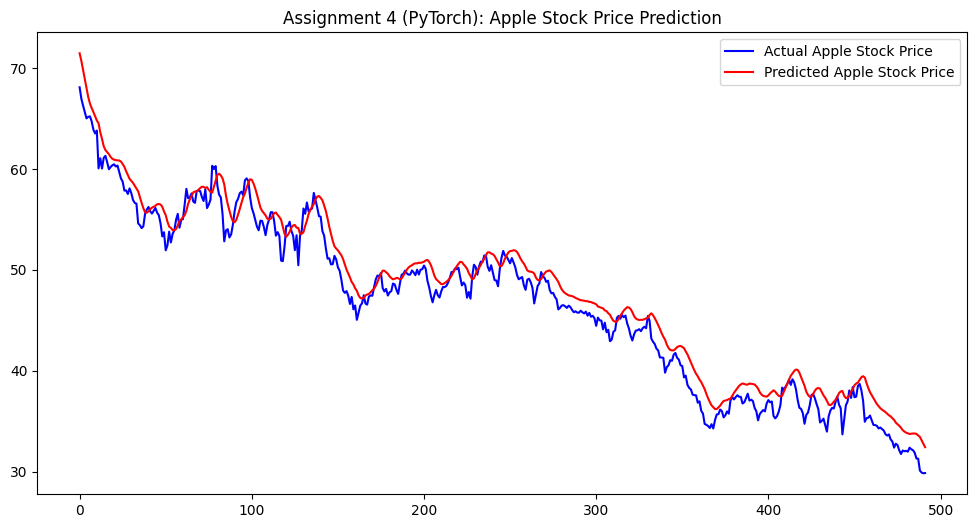

In [14]:
model.train()
for epoch in range(50):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/50], Loss: {epoch_loss/len(train_loader):.4f}")

# 7. Evaluation and Plotting
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.numpy())

plt.figure(figsize=(12, 6))
plt.plot(actual, color='blue', label='Actual Apple Stock Price')
plt.plot(predictions, color='red', label='Predicted Apple Stock Price')
plt.title('Assignment 4 (PyTorch): Apple Stock Price Prediction')
plt.legend()
plt.show()